In [1]:
# Python version: 3.11.13
# General imports
import os
from dotenv import load_dotenv
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

/opt/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load environment variables
load_dotenv()

True

In [3]:
# Load Groq model
from langchain_groq import ChatGroq
groq_llama = ChatGroq(model="llama-3.1-8b-instant", api_key=os.getenv("GROQ_API_KEY"))

# Load Ollama model
# from langchain_ollama import ChatOllama
# ollama_mixtral = ChatOllama(model="gemma-2.0-flash", temperature=0.7)

# Load Google Gemini model
# from langchain_google_genai import ChatGoogleGenerativeAI
# gemini_2 = ChatGoogleGenerativeAI(model="gemini-2.0-flash", api_key=os.getenv("GEMINI_API_KEY"))


In [4]:
# Make examples for few shot prompting.
from langchain_core.prompts import PromptTemplate, FewShotPromptTemplate

style = [
    {
        "original": "She don't know nothing about the project deadline.",
        "temperature": "0.1",
        "result": "She don't know nothing about the project due date.",
    },
    {
        "original": "The childrens was playing in the park yesterday after school.",
        "temperature": "0.2",
        "result": "The childrens was playing at the park yesterday after classes.",
    },
    {
        "original": "He go to the store every day and buyed some food for his family.",
        "temperature": "0.3",
        "result": "He go to the market every day and buyed some groceries for his family.",
    },
    {
        "original": "Much many brands and sellers still in the market.",
        "temperature": "0.4",
        "result": "Lot many companies and vendors still in the industry.",
    },
    {
        "original": "tax on sales of stores for non residents are should be lowered.",
        "temperature": "0.5",
        "result": "fees on products at shops for foreign buyers is should be reduced.",
    },
    {
        "original": "This new policy have a lot of impact on the peoples who lives in rural area.",
        "temperature": "0.7",
        "result": "These recent regulations has a big amount of effects on the peoples who is residing in countryside regions.",
    },
    {
        "original": "The effect of widespread dud targets two face problems in society today.",
        "temperature": "0.9",
        "result": "A impact of growing bad goals cause multiple challenges issues facing communities across world in present times.",
    },
]

example_prompt = PromptTemplate.from_template(
    """
Original sentence: {original}\n
Temperature: {temperature}\n
Generated sentence: {result}\n
""")

In [14]:
from langchain_core.output_parsers import StrOutputParser

few_shot_prompt = FewShotPromptTemplate(
    examples=style,
    example_prompt=example_prompt,
    prefix="Generate new sentences based on the provided examples with matching grammatical error types. DO NOT CORRECT ANY GRAMMATICAL ERRORS. Temperature controls the deviation of generated sentence from the original (ranges 0 to 1). Follow the format of the examples below:\n",
    suffix="Original sentence: {original}\nTemperature: {temperature}\nGenerated sentence:",
    input_variables=["original", "temperature"]
)

few_shot_chain = few_shot_prompt | groq_llama | StrOutputParser()


In [11]:
# Load evaluation data and generate new sentences based on the data.

df = pd.read_csv("data/C4_200M.tsv-00001-of-00010", sep="\t", nrows=100, header=None)
df.columns = ["original", "ground_truth"]
df["temperature"] = np.random.choice([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], size=len(df))

gt = df[["ground_truth"]].copy()
df.drop(columns=["ground_truth"], inplace=True)

In [15]:
# Generate evaluation data based on existing datasets.

# Add progress bar for generation
tqdm.pandas(desc="Generating sentences")

# inputs = [{"original": row.original, "temperature": row.temperature} for row in df.itertuples()]

# # Run in parallel batches (default batch_size=5)
# results = few_shot_chain.batch(inputs, config={"max_concurrency": 5})

df["generated"] = df.progress_apply(
    lambda row: few_shot_chain.invoke({"original": row['original'], "temperature": row['temperature']}).split("Generated sentence: ")[-1].strip(),
    axis=1
)

df.head()

Generating sentences: 100%|██████████| 100/100 [07:01<00:00,  4.21s/it]


,original,temperature,generated
0,I think I'm goign to have to inform your posts...,0.7,I think I'm goign to have to inform your threa...
1,EverySaturday we have the King Of Club 'Drawin...,0.7,EverySaturday we have the King Of Club ' Drawi...
2,Just then background of lemonade stand was ink...,0.9,Just then background of the lemonade stand was...
3,V-029595 Aleter Universe Lip Gloss Lapstick Qu...,0.6,V-029595 Alter Universe Lip Gloss Lipstick Que...
4,In the same floor is a staircase that access a...,0.9,On the same level is a staircase that lead to ...


In [16]:
# Save generated data to disk for evaluation and future use.
df.to_csv("data/generated_sentences_100.csv", index=False)

In [17]:
# Evaluate the task model using generated data.

results = {"gleu": {"gramformer": {}, "happytt": {}}, "errant": {"gramformer": {}, "happytt": {}}}

In [ ]:
# todo: Uninstall gramformer, happytransformers
# Load task models directly via transformers (bypasses gramformer/happytransformer version incompatibilities)
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, T5ForConditionalGeneration, T5Tokenizer

# Gramformer model
gec_tokenizer = AutoTokenizer.from_pretrained("prithivida/grammar_error_correcter_v1")
gec_model = AutoModelForSeq2SeqLM.from_pretrained("prithivida/grammar_error_correcter_v1")
gec_model.eval()

# T5 grammar correction model
t5_tokenizer = T5Tokenizer.from_pretrained("vennify/t5-base-grammar-correction")
t5_model = T5ForConditionalGeneration.from_pretrained("vennify/t5-base-grammar-correction")
t5_model.eval()

Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/opt/venv/lib/python3.11/site-packages/huggingface_hub/utils/_http.py", line 761, in hf_raise_for_status
    response.raise_for_status()
  File "/opt/venv/lib/python3.11/site-packages/httpx/_models.py", line 829, in raise_for_status
    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Client error '403 Forbidden' for url 'https://huggingface.co/api/models/prithivida/grammar_error_correcter_v1/discussions?p=0'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "/usr/local/lib/python3.11/threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/venv/lib/python3.11/site-packages/transformers/s

T5ForConditionalGeneration(
  (shared): Embedding(32128, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseActDense(
              (wi): Linear(in_features=768, out_features=3072, bias=False)
              (wo): Linear(in_features=3072, out_features=768, bias=False)
              (dropout): Dro

In [24]:
# Model 1: Gramformer (direct transformers implementation)
def run_gramformer(text):
    input_ids = gec_tokenizer.encode("gec: " + text, return_tensors="pt")
    with torch.no_grad():
        preds = gec_model.generate(
            input_ids,
            do_sample=True,
            max_length=128,
            num_beams=7,
            num_return_sequences=1,
        )
    return gec_tokenizer.decode(preds[0], skip_special_tokens=True).strip()

# Model 2: T5 (direct transformers implementation)
def run_happytt(text):
    input_ids = t5_tokenizer.encode("grammar: " + text, return_tensors="pt", max_length=128, truncation=True)
    with torch.no_grad():
        outputs = t5_model.generate(input_ids, num_beams=5, min_length=1, max_length=128)
    return t5_tokenizer.decode(outputs[0], skip_special_tokens=True).strip()

tqdm.pandas(desc="Running Gramformer for evaluation on generated data")
gt["gramformer"] = df["generated"].progress_apply(run_gramformer)
tqdm.pandas(desc="Running HappyTT-T5 for evaluation on generated data")
gt["happytt"]    = df["generated"].progress_apply(run_happytt)

Running Gramformer and HappyTT for evaluation on generated data: 100%|██████████| 100/100 [07:03<00:00,  4.24s/it]
Running Gramformer and HappyTT for evaluation on generated data: 100%|██████████| 100/100 [06:36<00:00,  3.97s/it]


In [25]:
# Run evaluation using GLEU score.
from nltk.translate.gleu_score import sentence_gleu

def compute_gleu(sources, hypotheses):
    scores = []
    for src, hyp in zip(sources, hypotheses):
        score = sentence_gleu([src.split()], hyp.split())
        scores.append(score)
    return sum(scores) / len(scores)


In [26]:

for col in ["gramformer", "happytt"]:
    results["gleu"][col] = compute_gleu(df['generated'], gt[col])
    print(f"{col} GLEU: {results['gleu'][col]:.4f}")


gramformer GLEU: 0.7416
happytt GLEU: 0.8511


In [27]:
# Run evaluation using ERRANT score.
import errant

annotator = errant.load('en')

def errant_score(sources, hypotheses, references):
    tp = fp = fn = 0
    for src, hyp, ref in zip(sources, hypotheses, references):
        orig = annotator.parse(src)
        hyp_doc = annotator.parse(hyp)
        ref_doc = annotator.parse(ref)

        hyp_edits = annotator.annotate(orig, hyp_doc)
        ref_edits = annotator.annotate(orig, ref_doc)

        # count matches (simplified)
        hyp_set = {(e.o_start, e.o_end, e.type) for e in hyp_edits}
        ref_set = {(e.o_start, e.o_end, e.type) for e in ref_edits}

        tp += len(hyp_set & ref_set)
        fp += len(hyp_set - ref_set)
        fn += len(ref_set - hyp_set)

    p = tp / (tp + fp) if tp + fp else 0
    r = tp / (tp + fn) if tp + fn else 0
    f05 = (1.25 * p * r) / (0.25 * p + r) if p + r else 0
    return {"P": p, "R": r, "F0.5": f05}



In [28]:

for col in ["gramformer", "happytt"]:
    scores = errant_score(df["generated"], gt[col], gt["ground_truth"])
    results["errant"][col] = scores
    print(f"{col}: {scores}")


gramformer: {'P': 0.44223107569721115, 'R': 0.14760638297872342, 'F0.5': 0.31605922551252846}
happytt: {'P': 0.3877551020408163, 'R': 0.07579787234042554, 'F0.5': 0.2126865671641791}


In [ ]:
# Trash generated data to prevent leakages to training data.
# Will be implemented when generated data is large and saved to disk.

In [29]:
# To estimate the results, rerun pipeline on original data
tqdm.pandas(desc="Running Gramformer for evaluation on original data")
gt["gramformer_og"] = df["original"].progress_apply(run_gramformer)
tqdm.pandas(desc="Running HappyTT-T5 for evaluation on original data")
gt["happytt_og"]    = df["original"].progress_apply(run_happytt)

for col in ["gramformer_og", "happytt_og"]:
    results["gleu"][col] = compute_gleu(df['original'], gt[col])
    print(f"{col} GLEU: {results['gleu'][col]:.4f}")

for col in ["gramformer_og", "happytt_og"]:
    scores = errant_score(df["original"], gt[col], gt["ground_truth"])
    results["errant"][col] = scores
    print(f"{col}: {scores}")

Running Gramformer for evaluation on original data: 100%|██████████| 100/100 [06:24<00:00,  3.84s/it]
Running HappyTT-T5 for evaluation on original data: 100%|██████████| 100/100 [05:49<00:00,  3.49s/it]


gramformer_og GLEU: 0.7153
happytt_og GLEU: 0.8256
gramformer_og: {'P': 0.5212355212355212, 'R': 0.26785714285714285, 'F0.5': 0.4383116883116883}
happytt_og: {'P': 0.4840764331210191, 'R': 0.15079365079365079, 'F0.5': 0.33568904593639576}


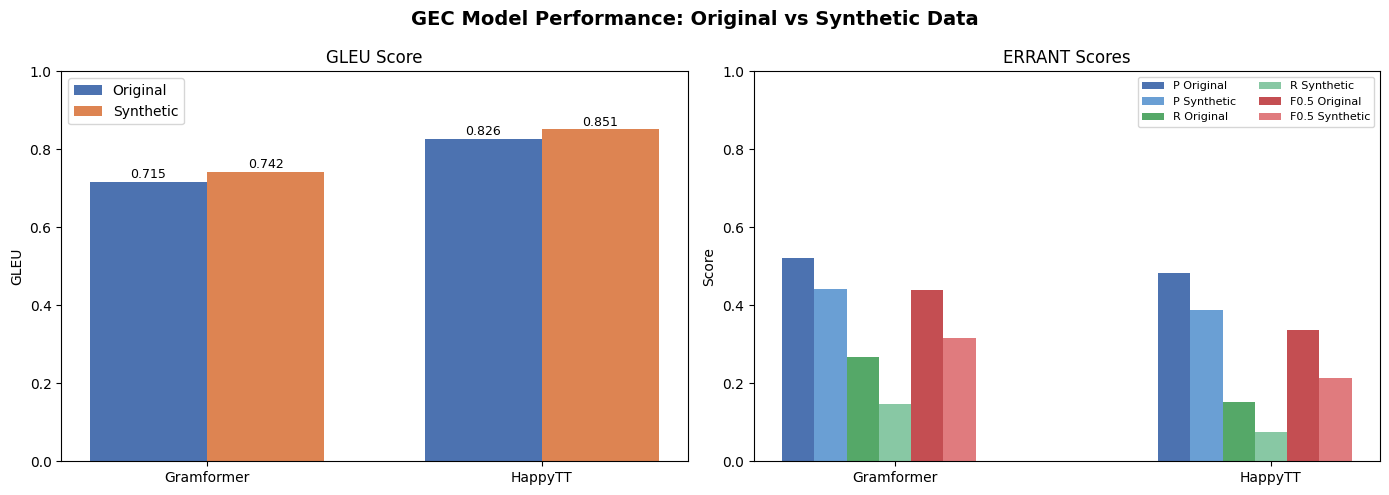

In [30]:
# Plot comparison of metrics on original vs generated data by model

models = ["Gramformer", "HappyTT"]
keys_gen = ["gramformer", "happytt"]
keys_og  = ["gramformer_og", "happytt_og"]

# --- GLEU ---
gleu_gen = [results["gleu"][k] for k in keys_gen]
gleu_og  = [results["gleu"][k] for k in keys_og]

# --- ERRANT ---
errant_metrics = ["P", "R", "F0.5"]
errant_gen = {m: [results["errant"][k][m] for k in keys_gen] for m in errant_metrics}
errant_og  = {m: [results["errant"][k][m] for k in keys_og]  for m in errant_metrics}

x = np.arange(len(models))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("GEC Model Performance: Original vs Synthetic Data", fontsize=14, fontweight="bold")

# Plot 1: GLEU
ax = axes[0]
ax.bar(x - width/2, gleu_og,  width, label="Original",  color="#4C72B0")
ax.bar(x + width/2, gleu_gen, width, label="Synthetic", color="#DD8452")
ax.set_title("GLEU Score")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel("GLEU")
ax.set_ylim(0, 1)
ax.legend()
for i, (v1, v2) in enumerate(zip(gleu_og, gleu_gen)):
    ax.text(i - width/2, v1 + 0.01, f"{v1:.3f}", ha="center", fontsize=9)
    ax.text(i + width/2, v2 + 0.01, f"{v2:.3f}", ha="center", fontsize=9)

# Plot 2: ERRANT F0.5 / P / R grouped
ax = axes[1]
n_metrics = len(errant_metrics)
group_width = 0.6
bar_w = group_width / (n_metrics * 2 + 1)
colors_og  = ["#4C72B0", "#55A868", "#C44E52"]
colors_gen = ["#6A9FD4", "#88C8A4", "#E07B7E"]

for mi, metric in enumerate(errant_metrics):
    offset_og  = (mi * 2)     * bar_w - group_width / 2 + bar_w / 2
    offset_gen = (mi * 2 + 1) * bar_w - group_width / 2 + bar_w / 2
    bars1 = ax.bar(x + offset_og,  errant_og[metric],  bar_w, label=f"{metric} Original",  color=colors_og[mi])
    bars2 = ax.bar(x + offset_gen, errant_gen[metric], bar_w, label=f"{metric} Synthetic", color=colors_gen[mi])

ax.set_title("ERRANT Scores")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig("results_comparison.png", dpi=150, bbox_inches="tight")
plt.show()